In [1]:
import os
import sys
import torch
import json
import plotly.express as px
from transformer_lens import utils
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
cwd = cwd.split("notebooks")[0]
print(cwd)
sys.path.append(cwd + "/scripts")
from error_eval import *
from plots import *

/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/


# Functions

In [2]:
length_list = list(range(1, 20, 2)) + list(range(20, 50, 4)) + list(range(51, 101, 10))
col_names_normal = [f'length_{length}_kl' for length in length_list]
col_names_l2_normal = [f'length_{length}_blocks.11.hook_resid_post_L2' for length in length_list]

def melt_by_col_names(df, col_names, id_vars = None):
    if id_vars:
        mean_df_melt = pd.melt(df, id_vars=id_vars, value_vars=col_names, ignore_index=False)
    else:
        mean_df_melt = pd.melt(df, value_vars=col_names, ignore_index=False)
    mean_df_melt["perturbation_length"] = mean_df_melt["variable"].str.split("_", expand = True)[1].astype(float)

    return mean_df_melt

# Compare Different Baselines

## For layer 6

In [69]:
layer_list = ["naive_random_itself", "cov_random_itself", "cov_random_mixture", "real_direction_mixture", "real_direction_itself"]

mean_df_dict = {}
sample_df_dict = {}

for layer in layer_list:
    print(layer)
    filename = f"{layer}_seed_23_layer_6_pos_all.csv"
    result_df = pd.read_csv(cwd + "/results/sensitive_direction/gpt2_resid_pre/" + filename)

    mean_df = pd.DataFrame(result_df.mean(axis=0)).T
    df_sample = result_df.sample(n = 10000)

    mean_df_dict[layer] = mean_df
    sample_df_dict[layer] = df_sample

naive_random_itself
cov_random_itself
cov_random_mixture
real_direction_mixture
real_direction_itself


In [70]:
mean_df_list = []
for layer in layer_list:
    mean_df = mean_df_dict[layer]
    mean_df["type"] = layer
    mean_df_list.append(mean_df)

mean_df_all = pd.concat(mean_df_list)

In [71]:
mean_df_all_melt_l2 = melt_by_col_names(mean_df_all, col_names_l2_normal, id_vars = ["type"])
mean_df_all_melt_l2["metric"] = "L2 distance at Layer 11 resid_post"

mean_df_all_melt_kl = melt_by_col_names(mean_df_all, col_names_normal, id_vars = ["type"])
mean_df_all_melt_kl["metric"] = "KL"

mean_df_all_melt = pd.concat([mean_df_all_melt_l2, mean_df_all_melt_kl])

col_labels = {
    'naive_random_itself': 'isotropic random',
    'cov_random_itself': 'cov-random difference',
    'cov_random_mixture': 'cov-random mixture-difference',
    'real_direction_itself': 'real difference',
    'real_direction_mixture': 'real mixture-difference',
}

In [72]:
mean_df_all_melt = mean_df_all_melt.replace({"type": col_labels})

In [73]:
include_list = ['cov-random difference', 'cov-random mixture-difference']

mean_df_all_melt_plot = mean_df_all_melt[mean_df_all_melt["type"].isin(include_list)]

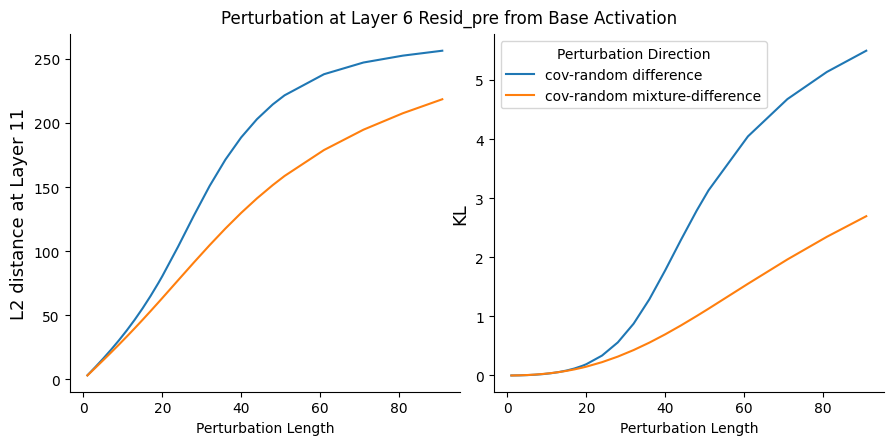

In [74]:
g = sns.FacetGrid(mean_df_all_melt_plot, col="metric", hue = "type", sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0)

g.set(xlabel="Perturbation Length", ylabel = None)
g.set_titles(col_template="", size = 15)

g.fig.suptitle('Perturbation at Layer 6 Resid_pre from Base Activation')
# plt.legend(title = "Perturbation Direction", bbox_to_anchor = [1.0, 0.6])
plt.legend(title = "Perturbation Direction")
# g.set(xlabel="Perturbation , ylabel = None)

g.axes[0,0].set_ylabel("L2 distance at Layer 11", fontsize = 13)
g.axes[0,1].set_ylabel('KL', fontsize = 13)


# plt.subplots_adjust(right=0.3)

plt.savefig(f"{cwd}/results/figures/sensitive_directions_cov_random.png", dpi = 500, bbox_inches = "tight")


In [75]:
include_list = ['real difference', 'real mixture-difference']

mean_df_all_melt_plot = mean_df_all_melt[mean_df_all_melt["type"].isin(include_list)]

In [76]:
mean_df_all_melt_plot = mean_df_all_melt_plot.sort_values("type")

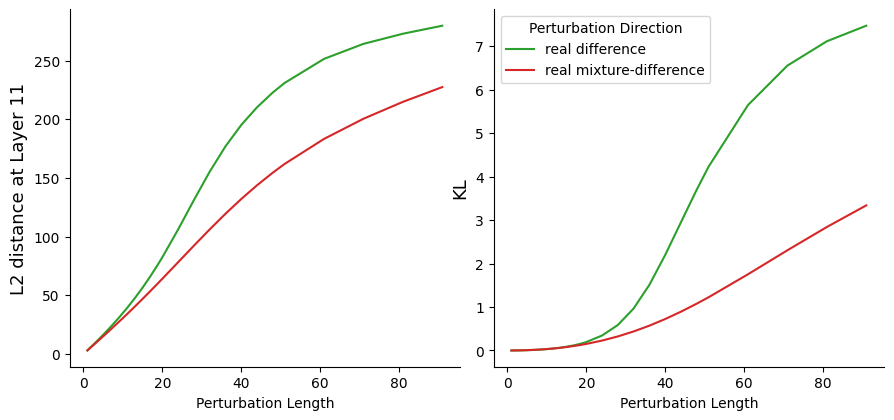

In [77]:
g = sns.FacetGrid(mean_df_all_melt_plot, col="metric", hue = "type",palette=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[3]], sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0)

g.set(xlabel="Perturbation Length", ylabel = None)
g.set_titles(col_template="", size = 15)

# g.set_title('Perturbation at Layer 6 Resid_pre from Base Activation')
# plt.legend(title = "Perturbation Direction", bbox_to_anchor = [1.0, 0.6])
plt.legend(title = "Perturbation Direction")
# g.set(xlabel="Perturbation , ylabel = None)

g.axes[0,0].set_ylabel("L2 distance at Layer 11", fontsize = 13)
g.axes[0,1].set_ylabel('KL', fontsize = 13)


# plt.subplots_adjust(right=0.3)

plt.savefig(f"{cwd}/results/figures/sensitive_directions_real.png", dpi = 500, bbox_inches = "tight")


In [78]:
include_list = ['isotropic random', 'cov-random mixture-difference', 'real mixture-difference']
mean_df_all_melt_plot = mean_df_all_melt[mean_df_all_melt["type"].isin(include_list)]

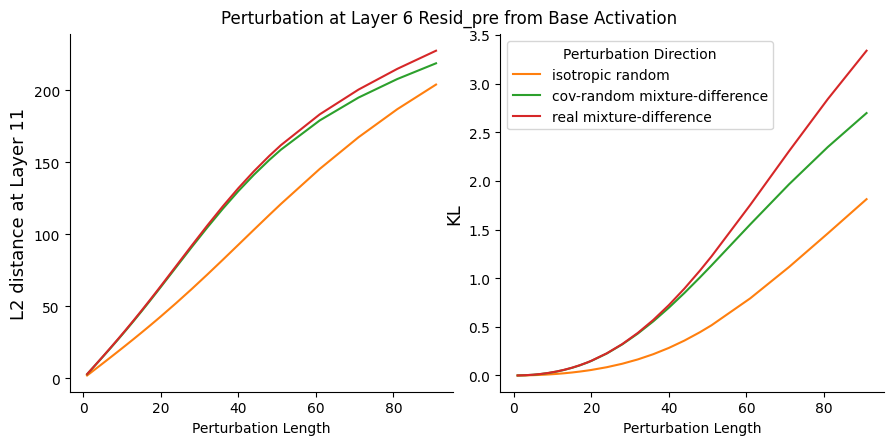

In [79]:
g = sns.FacetGrid(mean_df_all_melt_plot, col="metric", hue = "type", 
                  palette=[sns.color_palette("tab10")[1], sns.color_palette("tab10")[2], sns.color_palette("tab10")[3]], 
                  sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0)

g.fig.suptitle('Perturbation at Layer 6 Resid_pre from Base Activation')

g.set(xlabel="Perturbation Length", ylabel = None)
g.set_titles(col_template="", size = 15)

# g.set_title('Perturbation at Layer 6 Resid_pre from Base Activation')
# plt.legend(title = "Perturbation Direction", bbox_to_anchor = [1.0, 0.6])
plt.legend(title = "Perturbation Direction")
# g.set(xlabel="Perturbation , ylabel = None)

g.axes[0,0].set_ylabel("L2 distance at Layer 11", fontsize = 13)
g.axes[0,1].set_ylabel('KL', fontsize = 13)


# plt.subplots_adjust(right=0.3)

plt.savefig(f"{cwd}/results/figures/sensitive_directions.png", dpi = 500, bbox_inches = "tight")


## Now plot layer 2

In [80]:
layer_list = ["naive_random_itself", "cov_random_itself", "cov_random_mixture", "real_direction_mixture", "real_direction_itself"]

mean_df_dict = {}
sample_df_dict = {}

for layer in layer_list:
    print(layer)
    filename = f"{layer}_seed_23_layer_2_pos_all.csv"
    result_df = pd.read_csv(cwd + "/results/sensitive_direction/gpt2_resid_pre/" + filename)

    mean_df = pd.DataFrame(result_df.mean(axis=0)).T
    df_sample = result_df.sample(n = 10000)

    mean_df_dict[layer] = mean_df
    sample_df_dict[layer] = df_sample

naive_random_itself
cov_random_itself
cov_random_mixture
real_direction_mixture
real_direction_itself


In [81]:
mean_df_list = []
for layer in layer_list:
    mean_df = mean_df_dict[layer]
    mean_df["type"] = layer
    mean_df_list.append(mean_df)

mean_df_all = pd.concat(mean_df_list)

mean_df_all_melt_l2 = melt_by_col_names(mean_df_all, col_names_l2_normal, id_vars = ["type"])
mean_df_all_melt_l2["metric"] = "L2 distance at Layer 11 resid_post"

mean_df_all_melt_kl = melt_by_col_names(mean_df_all, col_names_normal, id_vars = ["type"])
mean_df_all_melt_kl["metric"] = "KL"

mean_df_all_melt = pd.concat([mean_df_all_melt_l2, mean_df_all_melt_kl])

col_labels = {
    'naive_random_itself': 'isotropic random',
    'cov_random_itself': 'cov-random difference',
    'cov_random_mixture': 'cov-random mixture-difference',
    'real_direction_itself': 'real difference',
    'real_direction_mixture': 'real mixture-difference',
}

In [82]:
mean_df_all_melt = mean_df_all_melt.replace({"type": col_labels})

include_list = ['cov-random difference', 'cov-random mixture-difference']
mean_df_all_melt_plot = mean_df_all_melt[mean_df_all_melt["type"].isin(include_list)]

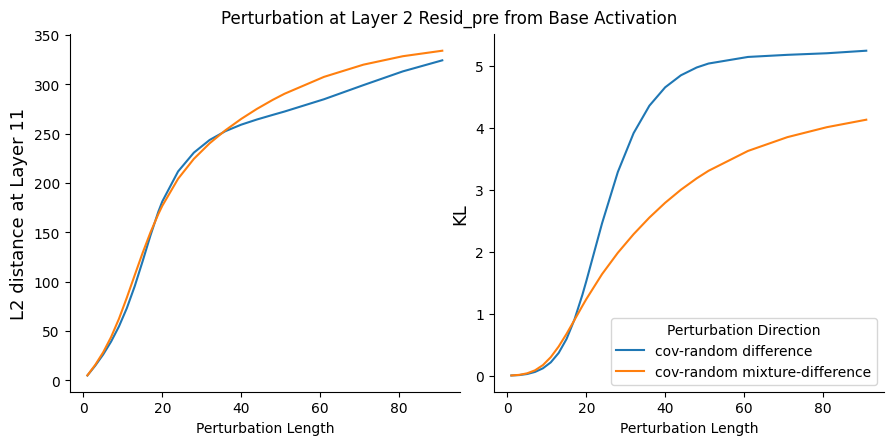

In [84]:
g = sns.FacetGrid(mean_df_all_melt_plot, col="metric", hue = "type", sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0)

g.set(xlabel="Perturbation Length", ylabel = None)
g.set_titles(col_template="", size = 15)

g.fig.suptitle('Perturbation at Layer 2 Resid_pre from Base Activation')
# plt.legend(title = "Perturbation Direction", bbox_to_anchor = [1.0, 0.6])
plt.legend(title = "Perturbation Direction")
# g.set(xlabel="Perturbation , ylabel = None)

g.axes[0,0].set_ylabel("L2 distance at Layer 11", fontsize = 13)
g.axes[0,1].set_ylabel('KL', fontsize = 13)


# plt.subplots_adjust(right=0.3)

plt.savefig(f"{cwd}/results/figures/sensitive_directions_cov_random_layer2.png", dpi = 500, bbox_inches = "tight")


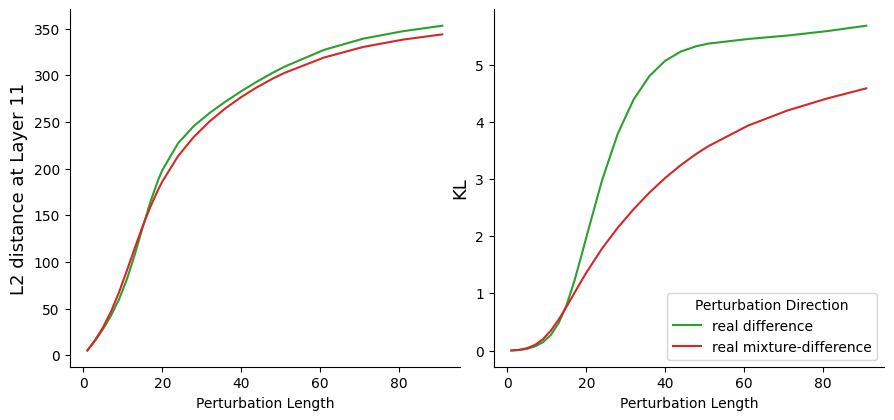

In [87]:
include_list = ['real difference', 'real mixture-difference']

mean_df_all_melt_plot = mean_df_all_melt[mean_df_all_melt["type"].isin(include_list)]

mean_df_all_melt_plot = mean_df_all_melt_plot.sort_values("type")

g = sns.FacetGrid(mean_df_all_melt_plot, col="metric", hue = "type",palette=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[3]], sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0)

g.set(xlabel="Perturbation Length", ylabel = None)
g.set_titles(col_template="", size = 15)

# g.set_title('Perturbation at Layer 6 Resid_pre from Base Activation')
# plt.legend(title = "Perturbation Direction", bbox_to_anchor = [1.0, 0.6])
plt.legend(title = "Perturbation Direction")
# g.set(xlabel="Perturbation , ylabel = None)

g.axes[0,0].set_ylabel("L2 distance at Layer 11", fontsize = 13)
g.axes[0,1].set_ylabel('KL', fontsize = 13)


# plt.subplots_adjust(right=0.3)

plt.savefig(f"{cwd}/results/figures/sensitive_directions_real_layer2.png", dpi = 500, bbox_inches = "tight")


In [92]:
include_list = ['isotropic random', 'cov-random mixture-difference', 'real mixture-difference']
mean_df_all_melt_plot = mean_df_all_melt[mean_df_all_melt["type"].isin(include_list)]

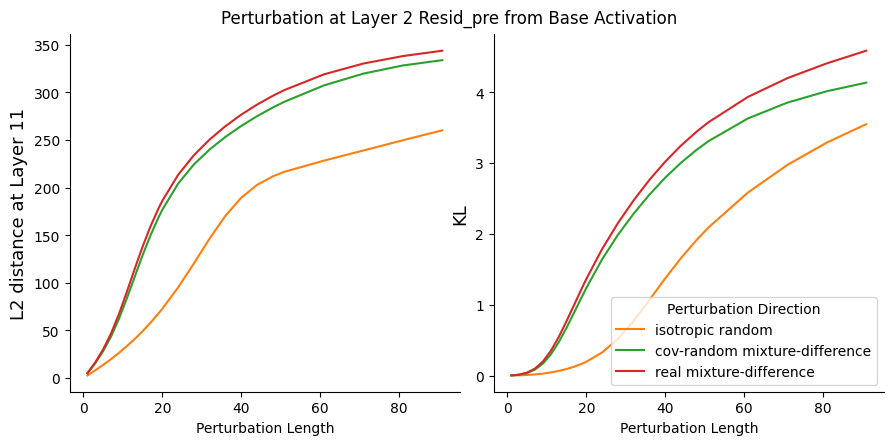

In [93]:
g = sns.FacetGrid(mean_df_all_melt_plot, col="metric", hue = "type", 
                  palette=[sns.color_palette("tab10")[1], sns.color_palette("tab10")[2], sns.color_palette("tab10")[3]], 
                  sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0)

g.fig.suptitle('Perturbation at Layer 2 Resid_pre from Base Activation')

g.set(xlabel="Perturbation Length", ylabel = None)
g.set_titles(col_template="", size = 15)

# g.set_title('Perturbation at Layer 6 Resid_pre from Base Activation')
# plt.legend(title = "Perturbation Direction", bbox_to_anchor = [1.0, 0.6])
plt.legend(title = "Perturbation Direction")
# g.set(xlabel="Perturbation , ylabel = None)

g.axes[0,0].set_ylabel("L2 distance at Layer 11", fontsize = 13)
g.axes[0,1].set_ylabel('KL', fontsize = 13)


# plt.subplots_adjust(right=0.3)

plt.savefig(f"{cwd}/results/figures/sensitive_directions_layer2.png", dpi = 500, bbox_inches = "tight")
